# 气压场水平剖面图绘制
## 固定高度固定时间点的水平气压剖面图绘制

使用时间索引: 122, time value = 7320.0
未找到精确匹配的zh，使用最接近值950.0（目标：1000，索引：9）
prs 变量维度名: ('time', 'zh', 'yh', 'xh'), 形状: (165, 78, 960, 960)
提取的气压场形状: (960, 960) (可能为 (xh, yh) 或 (yh, xh))
xh length: 960, yh length: 960
prs 范围: 90600.9765625 ~ 90601.078125


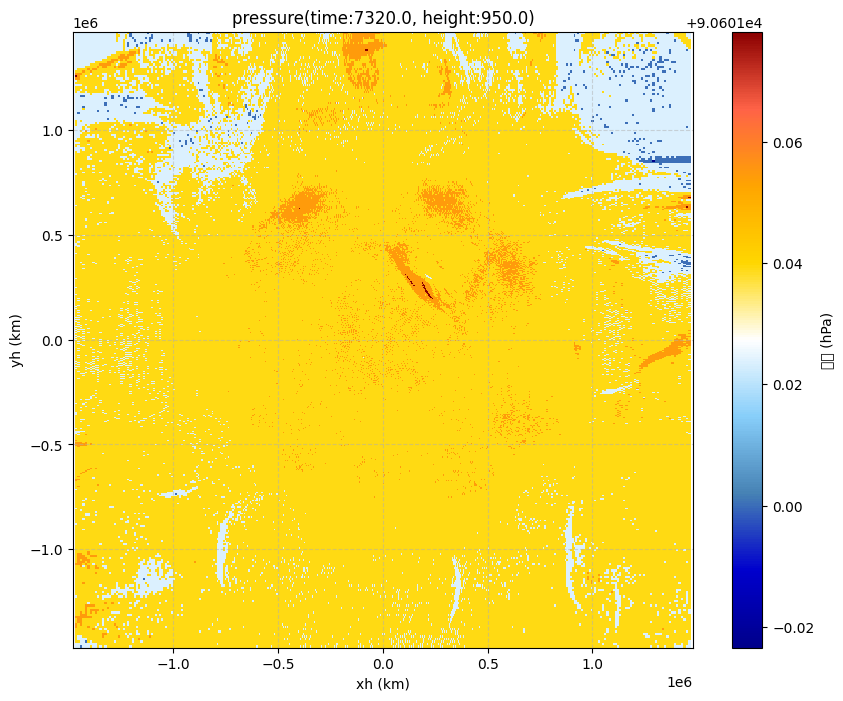

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from matplotlib.colors import LinearSegmentedColormap

# --------------------------
# 1. 设置参数（根据你的数据修改）
# --------------------------
nc_file = "dataset/cm1out_11.4.nc"  # 替换为你的.nc文件路径
target_time = 122  # 要固定的时间（可以是数值或索引，如第0时刻）
target_zh = 1000  # 要固定的高度（单位与数据一致，如1000米）
prs_var_name = "prs"  # 气压场变量名（短名称）

# 颜色映射设置（可选）
colors = ['#00008B', '#0000CD', '#4682B4', '#87CEFA', '#FFFFFF',
          '#FFD700', '#FFA500', '#FF6347', '#8B0000']
cmap = LinearSegmentedColormap.from_list("pressure_cmap", colors)

# --------------------------
# 辅助函数
# --------------------------
def find_index(arr, target, dim_name):
    """找到数组中与目标值最接近的索引（支持精确匹配）"""
    index = np.argmin(np.abs(arr - target))
    if np.isclose(arr[index], target):
        print(f"找到精确匹配的{dim_name}：{target}（索引：{index}）")
    else:
        print(f"未找到精确匹配的{dim_name}，使用最接近值{arr[index]}（目标：{target}，索引：{index}）")
    return int(index)

# --------------------------
# 2. 只读取必要变量 / 切片
# --------------------------
with Dataset(nc_file, mode='r') as nc:
    # 读取维度数组（通常这些很小，完整读取没有问题）
    time_arr = nc.variables['time'][:]
    zh_arr = nc.variables['zh'][:]
    xh = nc.variables['xh'][:]  # x坐标
    yh = nc.variables['yh'][:]  # y坐标

    # 确定 time 索引：如果 target_time 看起来是索引且在范围内则作为索引，否则按值查找最接近时间
    if isinstance(target_time, int) and 0 <= target_time < len(time_arr):
        time_idx = int(target_time)
        print(f"使用时间索引: {time_idx}, time value = {time_arr[time_idx]}")
    else:
        time_idx = find_index(time_arr, target_time, "time")

    # 确定高度索引（按值查找最接近）
    zh_idx = find_index(zh_arr, target_zh, "zh")

    # 获取气压变量对象（不立刻读取全部数据）
    if prs_var_name not in nc.variables:
        raise KeyError(f"{prs_var_name} 不在 nc 文件中，可用变量：{list(nc.variables.keys())}")
    prs_var = nc.variables[prs_var_name]

    print(f"prs 变量维度名: {prs_var.dimensions}, 形状: {prs_var.shape}")

    # 只读取所需的时间-高度切片（netCDF 支持按切片读取，不会把全部读入内存）
    # 假设维度顺序为 (time, zh, xh, yh)；若顺序不同，请根据 prs_var.dimensions 调整索引顺序
    pressure_slice = prs_var[time_idx, zh_idx, :, :]

# --------------------------
# 3. 检查并准备绘图数据（处理维度顺序不匹配的情况）
# --------------------------
print(f"提取的气压场形状: {pressure_slice.shape} (可能为 (xh, yh) 或 (yh, xh))")
print(f"xh length: {len(xh)}, yh length: {len(yh)}")
print(f"prs 范围: {np.nanmin(pressure_slice)} ~ {np.nanmax(pressure_slice)}")

# 确保与 xh/yh 对应：如果 pressure_slice.shape == (len(xh), len(yh))，则需要转置为 (len(yh), len(xh))
if pressure_slice.shape == (len(xh), len(yh)):
    Z = pressure_slice.T
elif pressure_slice.shape == (len(yh), len(xh)):
    Z = pressure_slice
else:
    # 若形状仍不匹配，则尝试自动转置并警告
    Z = pressure_slice
    print("警告：pressure_slice 形状与 xh/yh 长度不匹配，绘图可能出错。请检查变量维度顺序。")

# 创建网格并绘图
X, Y = np.meshgrid(xh, yh)

plt.figure(figsize=(10, 8))
mesh = plt.pcolormesh(X, Y, Z, cmap=cmap, shading='auto')
cbar = plt.colorbar(mesh, label='气压 (hPa)')
plt.title(f'pressure(time:{time_arr[time_idx]}, height:{zh_arr[zh_idx]})', fontsize=12)
plt.xlabel('xh (km)', fontsize=10)
plt.ylabel('yh (km)', fontsize=10)
plt.axis('equal')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## 特定高度的气压场的时间变化图


### 环境配置
在 Mac 上安装 ffmpeg

推荐用 Homebrew（macOS 常用、简单）。在终端执行：

- 若未安装 Homebrew，先安装：


In [ ]:
/bin/bash -c "$(curl -fsSL https://raw.githubusercontent.com/Homebrew/install/HEAD/install.sh)"



- 用 Homebrew 安装 ffmpeg：


In [ ]:
brew install ffmpeg



- 验证安装：


In [ ]:
ffmpeg -version



备选方法：
- conda（若用 Anaconda/Miniconda）：


In [ ]:
conda install -c conda-forge ffmpeg



- 或从 https://ffmpeg.org 下载 macOS 二进制并按说明安装。

在 VS Code 的集成终端中运行以上命令即可。如遇 PATH 问题（Apple Silicon），执行：


In [ ]:
eval "$(/opt/homebrew/bin/brew shellenv)"

### 绘图代码

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.animation as animation
import os

# 确保输出目录存在，并把输出文件放到 video 子目录
video_dir = "video"
os.makedirs(video_dir, exist_ok=True)

# --------------------------
# 参数（根据需要修改）
# --------------------------
nc_file = "dataset/cm1out_11.4.nc"
target_zh = 1000          # 固定的高度值
prs_var_name = "prs"
out_video = os.path.join(video_dir, "pressure_time_series_z{:.0f}.mp4".format(target_zh))
fps = 5  # 每秒帧数

colors = ['#00008B', '#0000CD', '#4682B4', '#87CEFA', '#FFFFFF',
          '#FFD700', '#FFA500', '#FF6347', '#8B0000']
cmap = LinearSegmentedColormap.from_list("pressure_cmap", colors)
# --------------------------
def find_index(arr, target, dim_name):
    index = np.argmin(np.abs(arr - target))
    if np.isclose(arr[index], target):
        print(f"找到精确匹配的{dim_name}：{target}（索引：{index}）")
    else:
        print(f"未找到精确匹配的{dim_name}，使用最接近值{arr[index]}（目标：{target}，索引：{index}）")
    return int(index)

# --------------------------
# 读取必要维度 & 逐帧读取气压切片并保存视频
# --------------------------
time_arr = None
zh_arr = None
xh = None
yh = None

# 显式打开 netCDF（不要用 with，保持打开直到动画保存完成）
nc = Dataset(nc_file, mode='r')
try:
    import matplotlib
    # 关闭交互绘图，避免 notebook 自动渲染触发回调访问已关闭的 nc 文件
    plt.ioff()
    
    # 读取小尺寸维度数组
    time_arr = nc.variables['time'][:]
    zh_arr = nc.variables['zh'][:]
    xh = nc.variables['xh'][:]   # x坐标
    yh = nc.variables['yh'][:]   # y坐标

    if prs_var_name not in nc.variables:
        raise KeyError(f"{prs_var_name} 不在 nc 文件中，可用变量：{list(nc.variables.keys())}")
    prs_var = nc.variables[prs_var_name]

    # 确定高度索引
    zh_idx = find_index(zh_arr, target_zh, "zh")
    ntime = len(time_arr)

    # 网格
    X, Y = np.meshgrid(xh, yh)

    # 先扫描所有时刻得到统一的 vmin/vmax（不把所有帧存入内存）
    data_min, data_max = np.inf, -np.inf
    for t in range(len(time_arr)):
        sl = prs_var[t, zh_idx, :, :]
        arr = np.asarray(sl, dtype=float)
        if np.all(np.isnan(arr)):
            continue
        data_min = min(data_min, np.nanmin(arr))
        data_max = max(data_max, np.nanmax(arr))
    if data_min == np.inf:  # 若全是 NaN，防护
        data_min, data_max = 0.0, 1.0

    # 辅助：把切片调整为与 X,Y 对应的形状 (len(yh), len(xh))
    def normalize_slice(arr2d):
        if arr2d.shape == (len(xh), len(yh)):
            return arr2d.T
        elif arr2d.shape == (len(yh), len(xh)):
            return arr2d
        else:
            print("警告：pressure_slice 形状与 xh/yh 长度不匹配，尝试按当前形状绘图。")
            return arr2d

    # 初始帧
    init_slice = prs_var[0, zh_idx, :, :]
    Z0 = normalize_slice(np.asarray(init_slice, dtype=float))

    fig, ax = plt.subplots(figsize=(10, 8))
    # 使用统一的 vmin/vmax，确保不同帧颜色一致
    mesh = ax.pcolormesh(X, Y, Z0, cmap=cmap, shading='auto', vmin=data_min, vmax=data_max)
    cbar = fig.colorbar(mesh, ax=ax, label='pressure (hPa)')
    ax.set_xlabel('xh (km)')
    ax.set_ylabel('yh (km)')
    ax.set_aspect('equal', 'box')
    ax.grid(True, linestyle='--', alpha=0.5)
# 动画更新函数
    def update(t):
        slice_t = prs_var[t, zh_idx, :, :]
        Z = normalize_slice(np.asarray(slice_t, dtype=float))

        ax.clear()
        mesh = ax.pcolormesh(X, Y, Z, cmap=cmap, shading='auto', vmin=data_min, vmax=data_max)
        ax.set_title(f'pressure(time:{time_arr[t]}, height:{zh_arr[zh_idx]})', fontsize=12)
        ax.set_xlabel('xh (km)')
        ax.set_ylabel('yh (km)')
        ax.set_aspect('equal', 'box')
        ax.grid(True, linestyle='--', alpha=0.5)
        return mesh,
# 创建动画
    ani = animation.FuncAnimation(fig, update, frames=range(len(time_arr)), blit=False)

    # 保存视频（需要系统安装 ffmpeg）
    print(f"开始保存视频到: {out_video}，请确保系统已安装 ffmpeg。")
    writer = animation.FFMpegWriter(fps=fps)
    ani.save(out_video, writer=writer)
    print(f"视频已保存: {out_video}")

    # 关闭 figure，并删除 ani，防止 notebook 后续自动渲染触发回调
    plt.close(fig)
    del ani
finally:
    nc.close()

未找到精确匹配的zh，使用最接近值950.0（目标：1000，索引：9）
开始保存视频到: video/pressure_time_series_z1000.mp4，请确保系统已安装 ffmpeg。
开始保存视频到: video/pressure_time_series_z1000.mp4，请确保系统已安装 ffmpeg。
视频已保存: video/pressure_time_series_z1000.mp4
视频已保存: video/pressure_time_series_z1000.mp4


# 水平截面图以及视频绘制封装函数

In [ ]:
"""
cm1_out_nc_plot.py
封装：从 netCDF 文件读取任意变量的水平剖面并绘图 / 生成时间序列视频。

主要改动：
 - 增加 PlotParams.start_time / end_time：可指定视频起止时间（索引或时间值）。不指定则用全时段。
 - 模块名改为 cm1_out_nc_plot

接口：
 - PlotParams: 参数容器，说明每个参数会改变什么。
 - plot_slice_once(params): 显示单帧（指定 time & zh）。
 - make_time_video(params): 在指定高度按时间生成视频（可指定起止时间段）。

说明：
 - 生成视频需要系统安装 ffmpeg（macOS 推荐 Homebrew: `brew install ffmpeg`）。
 - 若数据非常大，可设置 params.use_memory_read=True 将每帧读入内存（更快但占内存）。
"""
from dataclasses import dataclass
import os
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
import matplotlib.animation as animation
from matplotlib.colors import LinearSegmentedColormap

@dataclass
class PlotParams:
    # 必需
    nc_file: str                   # nc 文件路径
    var_name: str = "prs"          # 变量名
    target_zh: float = 1000.0      # 指定高度值（按 zh 维数组匹配）
    target_time: int = 0           # 单帧显示时的时间索引或时间值

    # 可选时间范围（用于生成视频）；可为索引或时间值；None 表示开始/结束取全时段
    start_time: object = None
    end_time: object = None

    # 维度名（若你的 nc 使用不同名称，请修改）
    zh_dim: str = "zh"
    time_dim: str = "time"
    x_dim: str = "xh"
    y_dim: str = "yh"

    # 可视化与输出
    cmap = None                    # matplotlib colormap，None 则使用默认
    vmin: float = None             # 强制颜色下限
    vmax: float = None             # 强制颜色上限
    fps: int = 5                   # 视频帧率
    video_dir: str = "video"       # 视频保存目录
    out_name: str = None           # 输出文件名（若 None 自动生成）
    save_video: bool = False       # 是否保存时间序列为视频
    use_memory_read: bool = False  # 是否一次性把所有帧读入内存
    verbose: bool = True

def _default_cmap():
    colors = ['#00008B', '#0000CD', '#4682B4', '#87CEFA', '#FFFFFF',
              '#FFD700', '#FFA500', '#FF6347', '#8B0000']
    return LinearSegmentedColormap.from_list("pressure_cmap", colors)

def _find_index(arr, target):
    return int(np.argmin(np.abs(arr - target)))

def _time_to_index(time_arr, key, default_idx):
    """把 key（索引或时间值或 None）转换为索引。"""
    if key is None:
        return default_idx
    if isinstance(key, int):
        if 0 <= key < len(time_arr):
            return int(key)
        # 若传入整数但超范围，寻找最近时间值
    # 以数值匹配最近值
    return _find_index(time_arr, key)

def plot_slice_once(params: PlotParams):
    """显示指定 time（或索引）和 height 的单帧图。"""
    cmap = params.cmap or _default_cmap()
    with Dataset(params.nc_file, "r") as nc:
        time_arr = nc.variables[params.time_dim][:]
        zh_arr = nc.variables[params.zh_dim][:]
        xh = nc.variables[params.x_dim][:]
        yh = nc.variables[params.y_dim][:]
        if params.var_name not in nc.variables:
            raise KeyError(f"{params.var_name} 不在 nc 文件中。可用变量: {list(nc.variables.keys())}")
        var = nc.variables[params.var_name]

        # 解析时间索引
        if isinstance(params.target_time, int) and 0 <= params.target_time < len(time_arr):
            time_idx = int(params.target_time)
        else:
            time_idx = _find_index(time_arr, params.target_time)

        zh_idx = _find_index(zh_arr, params.target_zh)

        sl = np.asarray(var[time_idx, zh_idx, :, :], dtype=float)
        if sl.shape == (len(xh), len(yh)):
            Z = sl.T
        else:
            Z = sl

        extent = (np.min(xh), np.max(xh), np.min(yh), np.max(yh))
        plt.figure(figsize=(10, 8))
        im = plt.imshow(Z, origin='lower', extent=extent, cmap=cmap)
        plt.colorbar(im, label=params.var_name)
        plt.title(f"{params.var_name} time={time_arr[time_idx]} zh={zh_arr[zh_idx]}")
        plt.xlabel(params.x_dim)
        plt.ylabel(params.y_dim)
        plt.gca().set_aspect('equal', 'box')
        plt.grid(True, linestyle='--', alpha=0.4)
        plt.show()

def make_time_video(params: PlotParams):
    """按时间遍历指定高度生成视频；支持指定起止时间段（索引或时间值）。"""
    cmap = params.cmap or _default_cmap()
    os.makedirs(params.video_dir, exist_ok=True)

    nc = Dataset(params.nc_file, "r")
    try:
        time_arr = nc.variables[params.time_dim][:]
        zh_arr = nc.variables[params.zh_dim][:]
        xh = nc.variables[params.x_dim][:]
        yh = nc.variables[params.y_dim][:]
        if params.var_name not in nc.variables:
            raise KeyError(f"{params.var_name} 不在 nc 文件中。可用变量: {list(nc.variables.keys())}")
        var = nc.variables[params.var_name]

        zh_idx = _find_index(zh_arr, params.target_zh)
        ntime = len(time_arr)

        # 解析起止索引
        start_idx = _time_to_index(time_arr, params.start_time, 0)
        end_idx = _time_to_index(time_arr, params.end_time, ntime - 1)
        # 保护：确保 start <= end 且在范围内
        start_idx = max(0, min(start_idx, ntime - 1))
        end_idx = max(0, min(end_idx, ntime - 1))
        if end_idx < start_idx:
            start_idx, end_idx = end_idx, start_idx

        if params.out_name:
            out_video = os.path.join(params.video_dir, params.out_name)
        else:
            out_video = os.path.join(params.video_dir,
                                     f"{params.var_name}_z{int(params.target_zh)}_t{start_idx}-{end_idx}.mp4")

        extent = (np.min(xh), np.max(xh), np.min(yh), np.max(yh))

        # 计算统一色标 vmin/vmax（如果用户未指定）
        if params.vmin is None or params.vmax is None:
            data_min, data_max = np.inf, -np.inf
            for t in range(start_idx, end_idx + 1):
                arr = np.asarray(var[t, zh_idx, :, :], dtype=float)
                if np.all(np.isnan(arr)):
                    continue
                data_min = min(data_min, np.nanmin(arr))
                data_max = max(data_max, np.nanmax(arr))
            if data_min == np.inf:
                data_min, data_max = 0.0, 1.0
            vmin = params.vmin if params.vmin is not None else data_min
            vmax = params.vmax if params.vmax is not None else data_max
        else:
            vmin, vmax = params.vmin, params.vmax

        # 预读全部帧（可选）
        if params.use_memory_read:
            frames = []
            for t in range(start_idx, end_idx + 1):
                arr = np.asarray(var[t, zh_idx, :, :], dtype=float)
                if arr.shape == (len(xh), len(yh)):
                    arr = arr.T
                frames.append(arr)
        else:
            frames = None

        plt.ioff()
        fig, ax = plt.subplots(figsize=(10, 8))
        if frames is not None:
            Z0 = frames[0]
        else:
            Z0 = np.asarray(var[start_idx, zh_idx, :, :], dtype=float)
            if Z0.shape == (len(xh), len(yh)):
                Z0 = Z0.T

        im = ax.imshow(Z0, origin='lower', extent=extent, cmap=cmap, vmin=vmin, vmax=vmax)
        cbar = fig.colorbar(im, ax=ax, label=params.var_name)
        title = ax.set_title("")
        ax.set_xlabel(params.x_dim)
        ax.set_ylabel(params.y_dim)
        ax.set_aspect('equal', 'box')
        ax.grid(True, linestyle='--', alpha=0.4)

        def _get_frame(idx):
            if frames is not None:
                return frames[idx - start_idx]
            else:
                sl = np.asarray(var[idx, zh_idx, :, :], dtype=float)
                if sl.shape == (len(xh), len(yh)):
                    sl = sl.T
                return sl

        def update(t):
            Z = _get_frame(t)
            im.set_data(Z)
            title.set_text(f"{params.var_name} time={time_arr[t]} zh={zh_arr[zh_idx]}")
            return (im, title)

        ani = animation.FuncAnimation(fig, update, frames=range(start_idx, end_idx + 1), blit=False)

        if params.save_video:
            writer = animation.FFMpegWriter(fps=params.fps)
            if params.verbose:
                print(f"开始保存视频到: {out_video}")
            ani.save(out_video, writer=writer)
            if params.verbose:
                print("保存完成:", out_video)
        else:
            plt.show()

        plt.close(fig)
        del ani
    finally:
        nc.close()

# cm1_out_nc_plot 使用说明

## 1. 简介
cm1_out_nc_plot.py 提供从 netCDF (.nc) 文件读取任意变量的水平剖面并：
- 显示指定高度、指定时间的单帧水平截面图（plot_slice_once）
- 在指定高度按时间生成动画并可保存为 mp4（make_time_video）

默认输出目录为工作区下的 `video` 子目录。

## 2. 依赖
- Python 库：numpy, matplotlib, netCDF4
- 生成 mp4 需要系统安装 ffmpeg（macOS 推荐 Homebrew）：
  - 安装 Homebrew（如未安装）：
    /bin/bash -c "$(curl -fsSL https://raw.githubusercontent.com/Homebrew/install/HEAD/install.sh)"
  - 安装 ffmpeg：
    brew install ffmpeg
  - 或使用 conda：
    conda install -c conda-forge ffmpeg

如遇 PATH 问题（Apple Silicon），可运行：
```
eval "$(/opt/homebrew/bin/brew shellenv)"
```

## 3. 快速使用示例

- 显示单帧：
```python
from cm1_out_nc_plot import PlotParams, plot_slice_once

params = PlotParams(
    nc_file="dataset/cm1out_11.4.nc",
    var_name="prs",
    target_zh=1000,
    target_time=122
)
plot_slice_once(params)
```

- 生成整个时段视频并保存：
```python
from cm1_out_nc_plot import PlotParams, make_time_video

params = PlotParams(
    nc_file="dataset/cm1out_11.4.nc",
    var_name="prs",
    target_zh=1000,
    save_video=True,
    fps=6
)
make_time_video(params)
```

- 生成部分时间段（索引或时间值）：
```python
params = PlotParams(
    nc_file="dataset/cm1out_11.4.nc",
    var_name="prs",
    target_zh=1000,
    start_time=10,    # 索引或时间值
    end_time=50,
    save_video=True
)
make_time_video(params)
```

## 4. 参数说明（主要字段）
- nc_file (str)：netCDF 文件路径（必需）。
- var_name (str)：要绘制的变量名，默认 "prs"。
- target_zh (float)：目标高度（按 nc 中 zh 数组匹配最近值）。
- target_time (int/float)：单帧显示的时间索引或时间值（整数且在范围内视为索引）。
- start_time / end_time (int/float/None)：生成视频的起止时间（索引或时间值），None 表示使用全时间段。
- zh_dim/time_dim/x_dim/y_dim (str)：维度名，默认 "zh","time","xh","yh"。
- cmap：matplotlib colormap，None 使用模块默认渐变。
- vmin / vmax (float/None)：强制颜色下/上限；None 则在所选时间段内自动计算统一色标。
- fps (int)：视频帧率（默认 5）。
- video_dir (str)：视频保存目录（默认 "video"）。
- out_name (str/None)：输出文件名；None 则自动命名为 `{var}_z{zh}_t{start}-{end}.mp4`。
- save_video (bool)：是否保存为 mp4（True 保存）。
- use_memory_read (bool)：是否预读所有帧到内存（适合短序列）。
- verbose (bool)：是否输出过程信息。

## 5. 细节与注意事项
- 切片维度假设为 (time, zh, x, y)。若变量维度顺序不同，请调整代码或维度名。
- 若不指定 vmin/vmax，代码会在 start_time..end_time 范围内扫描得到统一色标（按需可节省内存）。
- 若视频未生成，确认 ffmpeg 可在终端运行：`ffmpeg -version`，并确保 `save_video=True`。
- 对长时序或大网格建议使用 use_memory_read=False（按帧读取以节省内存）。
- 输出目录可为绝对路径或相对路径，模块会自动创建目录。

## 6. 常见问题
- 颜色范围不合理：显式设置 params.vmin / params.vmax。
- 时间/高度匹配错误：打印 nc 文件中的 time/zh 数组核对单位与数值。
- ffmpeg 找不到：确认安装并在 PATH 中可用，或在终端运行 Homebrew shellenv。

## 7. 进一步帮助
需要我将此 README 写入工作区（已完成）或根据你的 nc 文件维度进一步调整代码，请告知文件路径与维度信息（例如变量的 dimensions 列表）。// filepath: /Volumes/T7 Shield/科研/数值模式cm1/README_plot.md
# cm1_out_nc_plot 使用说明

## 1. 简介
cm1_out_nc_plot.py 提供从 netCDF (.nc) 文件读取任意变量的水平剖面并：
- 显示指定高度、指定时间的单帧水平截面图（plot_slice_once）
- 在指定高度按时间生成动画并可保存为 mp4（make_time_video）

默认输出目录为工作区下的 `video` 子目录。

## 2. 依赖
- Python 库：numpy, matplotlib, netCDF4
- 生成 mp4 需要系统安装 ffmpeg（macOS 推荐 Homebrew）：
  - 安装 Homebrew（如未安装）：
    /bin/bash -c "$(curl -fsSL https://raw.githubusercontent.com/Homebrew/install/HEAD/install.sh)"
  - 安装 ffmpeg：
    brew install ffmpeg
  - 或使用 conda：
    conda install -c conda-forge ffmpeg

如遇 PATH 问题（Apple Silicon），可运行：
```
eval "$(/opt/homebrew/bin/brew shellenv)"
```

## 3. 快速使用示例

- 显示单帧：
```python
from cm1_out_nc_plot import PlotParams, plot_slice_once

params = PlotParams(
    nc_file="dataset/cm1out_11.4.nc",
    var_name="prs",
    target_zh=1000,
    target_time=122
)
plot_slice_once(params)
```

- 生成整个时段视频并保存：
```python
from cm1_out_nc_plot import PlotParams, make_time_video

params = PlotParams(
    nc_file="dataset/cm1out_11.4.nc",
    var_name="prs",
    target_zh=1000,
    save_video=True,
    fps=6
)
make_time_video(params)
```

- 生成部分时间段（索引或时间值）：
```python
params = PlotParams(
    nc_file="dataset/cm1out_11.4.nc",
    var_name="prs",
    target_zh=1000,
    start_time=10,    # 索引或时间值
    end_time=50,
    save_video=True
)
make_time_video(params)
```

## 4. 参数说明（主要字段）
- nc_file (str)：netCDF 文件路径（必需）。
- var_name (str)：要绘制的变量名，默认 "prs"。
- target_zh (float)：目标高度（按 nc 中 zh 数组匹配最近值）。
- target_time (int/float)：单帧显示的时间索引或时间值（整数且在范围内视为索引）。
- start_time / end_time (int/float/None)：生成视频的起止时间（索引或时间值），None 表示使用全时间段。
- zh_dim/time_dim/x_dim/y_dim (str)：维度名，默认 "zh","time","xh","yh"。
- cmap：matplotlib colormap，None 使用模块默认渐变。
- vmin / vmax (float/None)：强制颜色下/上限；None 则在所选时间段内自动计算统一色标。
- fps (int)：视频帧率（默认 5）。
- video_dir (str)：视频保存目录（默认 "video"）。
- out_name (str/None)：输出文件名；None 则自动命名为 `{var}_z{zh}_t{start}-{end}.mp4`。
- save_video (bool)：是否保存为 mp4（True 保存）。
- use_memory_read (bool)：是否预读所有帧到内存（适合短序列）。
- verbose (bool)：是否输出过程信息。

## 5. 细节与注意事项
- 切片维度假设为 (time, zh, x, y)。若变量维度顺序不同，请调整代码或维度名。
- 若不指定 vmin/vmax，代码会在 start_time..end_time 范围内扫描得到统一色标（按需可节省内存）。
- 若视频未生成，确认 ffmpeg 可在终端运行：`ffmpeg -version`，并确保 `save_video=True`。
- 对长时序或大网格建议使用 use_memory_read=False（按帧读取以节省内存）。
- 输出目录可为绝对路径或相对路径，模块会自动创建目录。

## 6. 常见问题
- 颜色范围不合理：显式设置 params.vmin / params.vmax。
- 时间/高度匹配错误：打印 nc 文件中的 time/zh 数组核对单位与数值。
- ffmpeg 找不到：确认安装并在 PATH 中可用，或在终端运行 Homebrew shellenv。

## 7. 进一步帮助
需要我将此 README 写入工作区（已完成）或根据你的 nc 文件维度进一步调整代码，请告知文件路径与维度信息（例如变量的 dimensions 列表）。

In [6]:
from cm1_out_nc_plot import PlotParams, plot_slice_once
params = PlotParams(
    nc_file="dataset/cm1out.nc",
    var_name="prs",
    target_zh=2,
    target_time=400,
    xy_limit=1000.0,
)
plot_slice_once(params)

TypeError: __init__() got an unexpected keyword argument 'xy_limit'

In [19]:
from cm1_out_nc_plot import PlotParams, plot_slice_once, make_time_video
params = PlotParams(
    nc_file="dataset/cm1out_11.4.nc",
    var_name="prs",
    target_zh=1000,
    start_time=10,    # 索引或时间值
    end_time=50,
    save_video=True
)
make_time_video(params)

/Users/zhangyuxuan/Library/Python/3.9/lib/python/site-packages/matplotlib/animation.py:872: UserWarning: Animation was deleted without rendering anything. This is most likely not intended. To prevent deletion, assign the Animation to a variable, e.g. `anim`, that exists until you output the Animation using `plt.show()` or `anim.save()`.
  warnings.warn(


开始保存视频到: video/prs_z1000_t10-50.mp4
保存完成: video/prs_z1000_t10-50.mp4


In [25]:
from cm1_out_nc_plot import PlotParams, plot_slice_once, make_time_video
params = PlotParams(
    nc_file="dataset/cm1out.nc",
    var_name="prs",
    target_zh=1,
    fps=20,
    start_time=0,
    end_time=881,
    save_video=True
)
make_time_video(params)

开始保存视频到: video/prs_z1_t0-881.mp4
保存完成: video/prs_z1_t0-881.mp4


## 新生成单帧水平场

已保存静帧图片： figure/prs_time_360000_zh_2.0078948.png


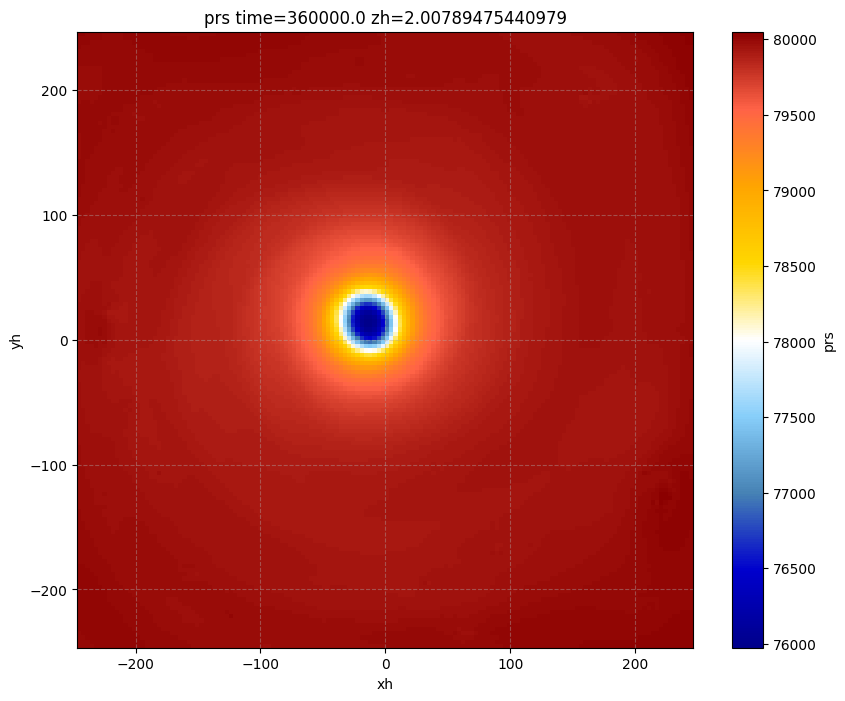

In [10]:
from plot_single_frame import PlotParams, plot_slice_once

params = PlotParams(
    nc_file="dataset/cm1out.nc",
    var_name="prs",
    target_zh=2,
    target_time=400,     # 整数当索引；也可传浮点时间值
    xy_limit=250.0,     # 只绘制 xh,yh ∈ [-1000,1000]
    figure_dir="figure",
    figure_name=None,    # None 则自动命名
    vmin=None, vmax=None,
    verbose=True,
    show=True
)
plot_slice_once(params)

In [1]:
from cm1_psfc_min_smoother import find_smoothed_min_point

res = find_smoothed_min_point(
    "dataset/cm1out.nc",
    time_key=400,          # 或 time_key=3600.0（秒）
    var_name="psfc",
    x_dim="xh",
    y_dim="yh",
    window=21,
    verbose=True
)
print(res)

使用 time index = 400, time value = 360000.0
全域最小值在数组索引 (iy,ix)=(254,246)，坐标 (x,y)=(-10.500000953674316,13.500000953674316)
读取子域索引 x [226,266], y [234,274]，子域形状 (41, 41)
central 21x21 在 region 内局部范围 x [10,30], y [10,30] 实际大小 (21,21)
结果: {'ix': 246, 'iy': 254, 'x': -10.500000953674316, 'y': 13.500000953674316, 'smoothed_value': 98595.64781746031, 'time_index': 400, 'time_value': 360000.0, 'central_window_indices': (236, 256, 244, 264)}
{'ix': 246, 'iy': 254, 'x': -10.500000953674316, 'y': 13.500000953674316, 'smoothed_value': 98595.64781746031, 'time_index': 400, 'time_value': 360000.0, 'central_window_indices': (236, 256, 244, 264)}


## 解指定高度的风廓线

In [ ]:
import numpy as np
from netCDF4 import Dataset
import os

# -----------------------------------------------------------
# 1. 参数设置
# -----------------------------------------------------------
nc_file = "dataset/cm1out.nc"
output_file = "dataset/typhoon_azimuthal_avg.nc"

# 假设 res 是你在之前单元格计算出的结果
# 如果是在脚本中运行，请确保 res 已经定义，或者手动指定
# res = {'x': 0.0, 'y': 0.0} # 示例
try:
    center_x = res['x']
    center_y = res['y']
    print(f"使用台风中心: x={center_x}, y={center_y}")
except NameError:
    # 如果 res 未定义（例如直接运行此脚本），请手动填入之前计算的值
    center_x = 0.0  # 请替换为实际值
    center_y = 0.0  # 请替换为实际值
    print(f"警告: res 变量未找到，使用默认中心: x={center_x}, y={center_y}")

# 时间索引：请确保这与计算 res 时使用的时间一致
# 之前的代码中使用了 time_key=400
t_idx = 400 

# 径向分箱设置 (单位: km)
max_r = 500.0   # 最大半径
dr = 2.0        # 半径步长
r_bins = np.arange(0, max_r + dr, dr)
r_centers = 0.5 * (r_bins[:-1] + r_bins[1:]) # 输出的 r 坐标

# -----------------------------------------------------------
# 2. 读取数据与去交错 (Destaggering)
# -----------------------------------------------------------
print(f"正在读取文件 {nc_file} (Time Index: {t_idx})...")
with Dataset(nc_file, 'r') as nc:
    # 读取坐标
    xh = nc.variables['xh'][:]  # km
    yh = nc.variables['yh'][:]  # km
    zh = nc.variables['zh'][:]  # km
    time_val = nc.variables['time'][t_idx]
    
    # 读取风场 (注意：只读取特定时间步以节省内存)
    # u: (time, zh, yh, xf) -> 需插值到 xh
    u_stag = nc.variables['u'][t_idx, :, :, :] 
    # v: (time, zh, yf, xh) -> 需插值到 yh
    v_stag = nc.variables['v'][t_idx, :, :, :]
    # w: (time, zf, yh, xh) -> 需插值到 zh
    w_stag = nc.variables['w'][t_idx, :, :, :]

print("正在进行网格去交错处理...")

# CM1 C-grid 去交错：取相邻点平均
# u(zh, yh, xf) -> u(zh, yh, xh)
# xf 长度通常比 xh 多 1，或者相等（取决于边界条件），通常取中间平均
if u_stag.shape[2] == len(xh) + 1:
    u_destag = 0.5 * (u_stag[:, :, :-1] + u_stag[:, :, 1:])
else:
    # 如果维度相同（周期性边界有时会这样），视情况处理，这里假设标准交错
    u_destag = 0.5 * (u_stag[:, :, :-1] + u_stag[:, :, 1:])

# v(zh, yf, xh) -> v(zh, yh, xh)
if v_stag.shape[1] == len(yh) + 1:
    v_destag = 0.5 * (v_stag[:, :-1, :] + v_stag[:, 1:, :])
else:
    v_destag = 0.5 * (v_stag[:, :-1, :] + v_stag[:, 1:, :])

# w(zf, yh, xh) -> w(zh, yh, xh)
if w_stag.shape[0] == len(zh) + 1:
    w_destag = 0.5 * (w_stag[:-1, :, :] + w_stag[1:, :, :])
else:
    w_destag = 0.5 * (w_stag[:-1, :, :] + w_stag[1:, :, :])

# -----------------------------------------------------------
# 3. 计算径向和切向风
# -----------------------------------------------------------
print("计算径向和切向风速...")

# 创建 2D 网格 (km)
X, Y = np.meshgrid(xh, yh) # shape: (ny, nx)

# 计算相对于台风中心的距离 R 和角度 Theta
# 注意：arctan2 返回的是数学角度（弧度），从 X 轴正向逆时针旋转
R_2d = np.sqrt((X - center_x)**2 + (Y - center_y)**2)
Theta_2d = np.arctan2(Y - center_y, X - center_x)

# 扩展维度以匹配高度层 (nz, ny, nx)
Theta_3d = np.tile(Theta_2d[np.newaxis, :, :], (len(zh), 1, 1))

# 投影风速
# Vr = u * cos(theta) + v * sin(theta)
# Vt = -u * sin(theta) + v * cos(theta) (逆时针/气旋式为正)
vr_3d = u_destag * np.cos(Theta_3d) + v_destag * np.sin(Theta_3d)
vt_3d = -u_destag * np.sin(Theta_3d) + v_destag * np.cos(Theta_3d)
w_3d = w_destag # 垂直速度不需要投影

# -----------------------------------------------------------
# 4. 方位角平均 (Binning)
# -----------------------------------------------------------
print("执行方位角平均...")

nz = len(zh)
nr = len(r_centers)

# 初始化输出数组 (nz, nr)
u_avg = np.zeros((nz, nr), dtype=np.float32) # 径向
v_avg = np.zeros((nz, nr), dtype=np.float32) # 切向
w_avg = np.zeros((nz, nr), dtype=np.float32) # 垂直

# 为了加速，先计算 2D 平面上的 bin 索引
# digitize 返回索引 i，满足 bins[i-1] <= x < bins[i]
# 我们只关心 1 到 len(bins)-1 的部分
bin_indices = np.digitize(R_2d.ravel(), r_bins)

# 逐层计算平均值
for k in range(nz):
    # 提取当前层的平展数据
    vr_flat = vr_3d[k, :, :].ravel()
    vt_flat = vt_3d[k, :, :].ravel()
    w_flat = w_3d[k, :, :].ravel()
    
    # 使用 bincount 进行快速求和与计数
    # minlength 确保结果长度足够
    count = np.bincount(bin_indices, minlength=len(r_bins)+1)
    sum_vr = np.bincount(bin_indices, weights=vr_flat, minlength=len(r_bins)+1)
    sum_vt = np.bincount(bin_indices, weights=vt_flat, minlength=len(r_bins)+1)
    sum_w  = np.bincount(bin_indices, weights=w_flat, minlength=len(r_bins)+1)
    
    # 计算平均值 (忽略索引0，因为它代表小于 r_bins[0] 的值，通常为空；以及超出范围的值)
    # r_centers 对应的是 bin_indices 1 到 len(r_centers)
    with np.errstate(divide='ignore', invalid='ignore'):
        avg_vr_layer = sum_vr / count
        avg_vt_layer = sum_vt / count
        avg_w_layer  = sum_w / count
    
    # 存入结果 (注意索引偏移，bin_indices=1 对应 r_centers[0])
    # 我们只需要 1 到 nr 的部分
    u_avg[k, :] = avg_vr_layer[1:nr+1]
    v_avg[k, :] = avg_vt_layer[1:nr+1]
    w_avg[k, :] = avg_w_layer[1:nr+1]

# 处理可能的 NaN (除以0的情况)
u_avg = np.nan_to_num(u_avg)
v_avg = np.nan_to_num(v_avg)
w_avg = np.nan_to_num(w_avg)

# -----------------------------------------------------------
# 5. 写入 NetCDF 文件
# -----------------------------------------------------------
print(f"写入输出文件: {output_file}")
if os.path.exists(output_file):
    os.remove(output_file)

with Dataset(output_file, 'w', format='NETCDF4') as nc_out:
    # 定义维度
    nc_out.createDimension('time', 1) # 单一时间步
    nc_out.createDimension('z', nz)
    nc_out.createDimension('r', nr)
    
    # 创建变量
    var_time = nc_out.createVariable('time', 'f4', ('time',))
    var_z = nc_out.createVariable('z', 'f4', ('z',)) # 或命名为 h
    var_r = nc_out.createVariable('r', 'f4', ('r',))
    
    var_u = nc_out.createVariable('u', 'f4', ('time', 'z', 'r'))
    var_v = nc_out.createVariable('v', 'f4', ('time', 'z', 'r'))
    var_w = nc_out.createVariable('w', 'f4', ('time', 'z', 'r'))
    
    # 写入属性
    var_r.units = 'km'
    var_r.long_name = 'radial distance'
    
    var_z.units = 'km'
    var_z.long_name = 'height (ASL)'
    
    var_time.units = 'seconds since simulation start'
    var_time.long_name = 'time'
    
    var_u.units = 'm s-1'
    var_u.long_name = 'radial velocity (outward positive)'
    
    var_v.units = 'm s-1'
    var_v.long_name = 'tangential velocity (cyclonic positive)'
    
    var_w.units = 'm s-1'
    var_w.long_name = 'vertical velocity'
    
    # 写入数据
    var_time[:] = np.array([time_val])
    var_z[:] = zh
    var_r[:] = r_centers
    
    # 增加 time 维度 (1, nz, nr)
    var_u[0, :, :] =# filepath: f:\科研\数值模式cm1\azimuthal_average.py
import numpy as np
from netCDF4 import Dataset
import os

# -----------------------------------------------------------
# 1. 参数设置
# -----------------------------------------------------------
nc_file = "dataset/cm1out.nc"
output_file = "dataset/typhoon_azimuthal_avg.nc"

# 假设 res 是你在之前单元格计算出的结果
# 如果是在脚本中运行，请确保 res 已经定义，或者手动指定
# res = {'x': 0.0, 'y': 0.0} # 示例
try:
    center_x = res['x']
    center_y = res['y']
    print(f"使用台风中心: x={center_x}, y={center_y}")
except NameError:
    # 如果 res 未定义（例如直接运行此脚本），请手动填入之前计算的值
    center_x = 0.0  # 请替换为实际值
    center_y = 0.0  # 请替换为实际值
    print(f"警告: res 变量未找到，使用默认中心: x={center_x}, y={center_y}")

# 时间索引：请确保这与计算 res 时使用的时间一致
# 之前的代码中使用了 time_key=400
t_idx = 400 

# 径向分箱设置 (单位: km)
max_r = 500.0   # 最大半径
dr = 2.0        # 半径步长
r_bins = np.arange(0, max_r + dr, dr)
r_centers = 0.5 * (r_bins[:-1] + r_bins[1:]) # 输出的 r 坐标

# -----------------------------------------------------------
# 2. 读取数据与去交错 (Destaggering)
# -----------------------------------------------------------
print(f"正在读取文件 {nc_file} (Time Index: {t_idx})...")
with Dataset(nc_file, 'r') as nc:
    # 读取坐标
    xh = nc.variables['xh'][:]  # km
    yh = nc.variables['yh'][:]  # km
    zh = nc.variables['zh'][:]  # km
    time_val = nc.variables['time'][t_idx]
    
    # 读取风场 (注意：只读取特定时间步以节省内存)
    # u: (time, zh, yh, xf) -> 需插值到 xh
    u_stag = nc.variables['u'][t_idx, :, :, :] 
    # v: (time, zh, yf, xh) -> 需插值到 yh
    v_stag = nc.variables['v'][t_idx, :, :, :]
    # w: (time, zf, yh, xh) -> 需插值到 zh
    w_stag = nc.variables['w'][t_idx, :, :, :]

print("正在进行网格去交错处理...")

# CM1 C-grid 去交错：取相邻点平均
# u(zh, yh, xf) -> u(zh, yh, xh)
# xf 长度通常比 xh 多 1，或者相等（取决于边界条件），通常取中间平均
if u_stag.shape[2] == len(xh) + 1:
    u_destag = 0.5 * (u_stag[:, :, :-1] + u_stag[:, :, 1:])
else:
    # 如果维度相同（周期性边界有时会这样），视情况处理，这里假设标准交错
    u_destag = 0.5 * (u_stag[:, :, :-1] + u_stag[:, :, 1:])

# v(zh, yf, xh) -> v(zh, yh, xh)
if v_stag.shape[1] == len(yh) + 1:
    v_destag = 0.5 * (v_stag[:, :-1, :] + v_stag[:, 1:, :])
else:
    v_destag = 0.5 * (v_stag[:, :-1, :] + v_stag[:, 1:, :])

# w(zf, yh, xh) -> w(zh, yh, xh)
if w_stag.shape[0] == len(zh) + 1:
    w_destag = 0.5 * (w_stag[:-1, :, :] + w_stag[1:, :, :])
else:
    w_destag = 0.5 * (w_stag[:-1, :, :] + w_stag[1:, :, :])

# -----------------------------------------------------------
# 3. 计算径向和切向风
# -----------------------------------------------------------
print("计算径向和切向风速...")

# 创建 2D 网格 (km)
X, Y = np.meshgrid(xh, yh) # shape: (ny, nx)

# 计算相对于台风中心的距离 R 和角度 Theta
# 注意：arctan2 返回的是数学角度（弧度），从 X 轴正向逆时针旋转
R_2d = np.sqrt((X - center_x)**2 + (Y - center_y)**2)
Theta_2d = np.arctan2(Y - center_y, X - center_x)

# 扩展维度以匹配高度层 (nz, ny, nx)
Theta_3d = np.tile(Theta_2d[np.newaxis, :, :], (len(zh), 1, 1))

# 投影风速
# Vr = u * cos(theta) + v * sin(theta)
# Vt = -u * sin(theta) + v * cos(theta) (逆时针/气旋式为正)
vr_3d = u_destag * np.cos(Theta_3d) + v_destag * np.sin(Theta_3d)
vt_3d = -u_destag * np.sin(Theta_3d) + v_destag * np.cos(Theta_3d)
w_3d = w_destag # 垂直速度不需要投影

# -----------------------------------------------------------
# 4. 方位角平均 (Binning)
# -----------------------------------------------------------
print("执行方位角平均...")

nz = len(zh)
nr = len(r_centers)

# 初始化输出数组 (nz, nr)
u_avg = np.zeros((nz, nr), dtype=np.float32) # 径向
v_avg = np.zeros((nz, nr), dtype=np.float32) # 切向
w_avg = np.zeros((nz, nr), dtype=np.float32) # 垂直

# 为了加速，先计算 2D 平面上的 bin 索引
# digitize 返回索引 i，满足 bins[i-1] <= x < bins[i]
# 我们只关心 1 到 len(bins)-1 的部分
bin_indices = np.digitize(R_2d.ravel(), r_bins)

# 逐层计算平均值
for k in range(nz):
    # 提取当前层的平展数据
    vr_flat = vr_3d[k, :, :].ravel()
    vt_flat = vt_3d[k, :, :].ravel()
    w_flat = w_3d[k, :, :].ravel()
    
    # 使用 bincount 进行快速求和与计数
    # minlength 确保结果长度足够
    count = np.bincount(bin_indices, minlength=len(r_bins)+1)
    sum_vr = np.bincount(bin_indices, weights=vr_flat, minlength=len(r_bins)+1)
    sum_vt = np.bincount(bin_indices, weights=vt_flat, minlength=len(r_bins)+1)
    sum_w  = np.bincount(bin_indices, weights=w_flat, minlength=len(r_bins)+1)
    
    # 计算平均值 (忽略索引0，因为它代表小于 r_bins[0] 的值，通常为空；以及超出范围的值)
    # r_centers 对应的是 bin_indices 1 到 len(r_centers)
    with np.errstate(divide='ignore', invalid='ignore'):
        avg_vr_layer = sum_vr / count
        avg_vt_layer = sum_vt / count
        avg_w_layer  = sum_w / count
    
    # 存入结果 (注意索引偏移，bin_indices=1 对应 r_centers[0])
    # 我们只需要 1 到 nr 的部分
    u_avg[k, :] = avg_vr_layer[1:nr+1]
    v_avg[k, :] = avg_vt_layer[1:nr+1]
    w_avg[k, :] = avg_w_layer[1:nr+1]

# 处理可能的 NaN (除以0的情况)
u_avg = np.nan_to_num(u_avg)
v_avg = np.nan_to_num(v_avg)
w_avg = np.nan_to_num(w_avg)

# -----------------------------------------------------------
# 5. 写入 NetCDF 文件
# -----------------------------------------------------------
print(f"写入输出文件: {output_file}")
if os.path.exists(output_file):
    os.remove(output_file)

with Dataset(output_file, 'w', format='NETCDF4') as nc_out:
    # 定义维度
    nc_out.createDimension('time', 1) # 单一时间步
    nc_out.createDimension('z', nz)
    nc_out.createDimension('r', nr)
    
    # 创建变量
    var_time = nc_out.createVariable('time', 'f4', ('time',))
    var_z = nc_out.createVariable('z', 'f4', ('z',)) # 或命名为 h
    var_r = nc_out.createVariable('r', 'f4', ('r',))
    
    var_u = nc_out.createVariable('u', 'f4', ('time', 'z', 'r'))
    var_v = nc_out.createVariable('v', 'f4', ('time', 'z', 'r'))
    var_w = nc_out.createVariable('w', 'f4', ('time', 'z', 'r'))
    
    # 写入属性
    var_r.units = 'km'
    var_r.long_name = 'radial distance'
    
    var_z.units = 'km'
    var_z.long_name = 'height (ASL)'
    
    var_time.units = 'seconds since simulation start'
    var_time.long_name = 'time'
    
    var_u.units = 'm s-1'
    var_u.long_name = 'radial velocity (outward positive)'
    
    var_v.units = 'm s-1'
    var_v.long_name = 'tangential velocity (cyclonic positive)'
    
    var_w.units = 'm s-1'
    var_w.long_name = 'vertical velocity'
    
    # 写入数据
    var_time[:] = np.array([time_val])
    var_z[:] = zh
    var_r[:] = r_centers
    
    # 增加 time 维度 (1, nz, nr)
    var_u[0, :, :] = u_avg
    var_v[0, :, :] = v_avg
    var_w[0, :, :] = w_avg

print("处理完成！")

In [11]:
from extract_profile_along_x import profile_along_x
arr = profile_along_x("dataset/cm1out.nc",
                      time_idx=400,
                      prs_var="prs",
                      prs_zh_value=1.0,
                      psfc_var="psfc",
                      psfc_time_key=400,
                      stop_x_km=1000.0,
                      verbose=True)
#print(arr)
#with open("output_profile.txt", "w") as f:
#    for val in arr:
#        f.write(f"{val}\n") 
import numpy as np
import matplotlib.pyplot as plt
from netCDF4 import Dataset
from matplotlib.colors import LinearSegmentedColormap

# arr.shape == (N,2) 列为 [r_km, prs_hPa]
r_km = arr[:,0]
p_pa = arr[:,1]

#绘制r_km的一维散点图分布
#plt.figure(figsize=(8,6))
#plt.scatter(r_km, [0]*len(r_km), c='blue', s=10)

#plt.show()
r_m = r_km * 1000.0


N = len(r_m)
combined_data = np.column_stack((r_m, p_pa))

# 对数据进行平滑处理
from scipy.ndimage import gaussian_filter1d


# 创建更密集的径向网格进行插值
from scipy.interpolate import interp1d

# 线性插值
# 对r_m小于50000m时sigma参数采用1.5，对r_m在50000-100000m之间将sigma非线性用三角函数平滑提高到7
# 使用统一的sigma值进行平滑，避免不同区域使用不同平滑参数导致的断点
sigma = 10.0  # 统一平滑参数
p_pa_smooth = gaussian_filter1d(p_pa, sigma=sigma)
# 创建更密集的径向网格进行插值
r_m_dense = np.linspace(np.min(r_m), np.max(r_m), len(r_m) * 10)  # 增加到10倍密度以提高插值精度
interp_func = interp1d(r_m, p_pa_smooth, kind='cubic', bounds_error=False, fill_value='extrapolate')  # 使用三次样条插值
p_pa_interp = interp_func(r_m_dense)

# 使用插值后的数据进行计算
N_interp = len(r_m_dense)
dpdr = np.full(N_interp, np.nan)

if N_interp >= 2:
    # 内部点用中心差分
    for i in range(1, N_interp-1):
        dp = p_pa_interp[i+1] - p_pa_interp[i-1]
        dr = r_m_dense[i+1] - r_m_dense[i-1]
        dpdr[i] = dp / dr if dr != 0 else np.nan
    # 边界点用一侧差分
    dpdr[0] = (p_pa_interp[1] - p_pa_interp[0]) / (r_m_dense[1] - r_m_dense[0])
    dpdr[-1] = (p_pa_interp[-1] - p_pa_interp[-2]) / (r_m_dense[-1] - r_m_dense[-2])
rho = 1.293  # kg/m³
f = 5e-5     # Coriolis parameter, s⁻¹
vg = np.full(N_interp, np.nan)
for i in range(N_interp):
    vg[i] = 0.5 * (-f * r_m_dense[i] + np.sqrt((f * r_m_dense[i])**2 + 4 * r_m_dense[i] / rho * dpdr[i]))

# 将插值后的数据保存供后续使用
result_smooth = np.column_stack((r_m_dense/1000.0, p_pa_interp, dpdr, vg))
#接着计算dvg/dr
dvg_dr = np.full(N_interp, np.nan)
for i in range(1, N_interp-1):
    dvg = vg[i+1] - vg[i-1]
    dr = r_m_dense[i+1] - r_m_dense[i-1]
    dvg_dr[i] = dvg / dr if dr != 0 else np.nan
# 边界点用一侧差分
dvg_dr[0] = (vg[1] - vg[0]) / (r_m_dense[1] - r_m_dense[0])
dvg_dr[-1] = (vg[-1] - vg[-2]) / (r_m_dense[-1] - r_m_dense[-2])
zeta=np.full(N_interp, np.nan)
for i in range(N_interp):
    zeta[i]=dvg_dr[i] + vg[i]/r_m_dense[i]+ f if r_m_dense[i]!=0 else np.nan
xi=np.full(N_interp, np.nan)
for i in range(N_interp):
    xi[i]=2*vg[i]/r_m_dense[i]+ f if r_m_dense[i]!=0 else np.nan
#台风边界层湍流扩散系数
K=10.0  # m²/s
delta=np.full(N_interp, np.nan)
for i in range(N_interp):
    delta[i]=np.sqrt(K/np.sqrt(xi[i]*zeta[i])) 
result_A = np.column_stack((r_m_dense, vg, dvg_dr, zeta, xi, delta))



使用 time index = 400, time value = 360000.0
全域最小值在数组索引 (iy,ix)=(254,246)，坐标 (x,y)=(-10.500000953674316,13.500000953674316)
读取子域索引 x [226,266], y [234,274]，子域形状 (41, 41)
central 21x21 在 region 内局部范围 x [10,30], y [10,30] 实际大小 (21,21)
结果: {'ix': 246, 'iy': 254, 'x': -10.500000953674316, 'y': 13.500000953674316, 'smoothed_value': 98595.64781746031, 'time_index': 400, 'time_value': 360000.0, 'central_window_indices': (236, 256, 244, 264)}
psfc 平滑最小点 ix=246, iy=254, coord=(-10.500000953674316,13.500000953674316)
prs 使用 zh index=7, zh_value=0.9552632570266724
ix=246, xh=-10.500000953674316, r=0.0, prs=85819.1875
ix=247, xh=-7.500000476837158, r=3.000000476837158, prs=85896.15625
ix=248, xh=-4.5, r=6.000000953674316, prs=86057.1484375
ix=249, xh=-1.5000001192092896, r=9.000000834465027, prs=86397.09375
ix=250, xh=1.5000001192092896, r=12.000001072883606, prs=86946.4609375
ix=251, xh=4.5, r=15.000000953674316, prs=87575.5234375
ix=252, xh=7.500000476837158, r=18.000001430511475, prs=88145.789062

/var/folders/s2/z30rzjdj1_v3bf__fwxl9rg00000gn/T/ipykernel_78142/1466704248.py:91: RuntimeWarning: invalid value encountered in sqrt
  delta[i]=np.sqrt(K/np.sqrt(xi[i]*zeta[i]))


/var/folders/s2/z30rzjdj1_v3bf__fwxl9rg00000gn/T/ipykernel_78142/3654909441.py:32: UserWarning: Glyph 24452 (\N{CJK UNIFIED IDEOGRAPH-5F84}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/s2/z30rzjdj1_v3bf__fwxl9rg00000gn/T/ipykernel_78142/3654909441.py:32: UserWarning: Glyph 21521 (\N{CJK UNIFIED IDEOGRAPH-5411}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/s2/z30rzjdj1_v3bf__fwxl9rg00000gn/T/ipykernel_78142/3654909441.py:32: UserWarning: Glyph 36317 (\N{CJK UNIFIED IDEOGRAPH-8DDD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/s2/z30rzjdj1_v3bf__fwxl9rg00000gn/T/ipykernel_78142/3654909441.py:32: UserWarning: Glyph 31163 (\N{CJK UNIFIED IDEOGRAPH-79BB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/s2/z30rzjdj1_v3bf__fwxl9rg00000gn/T/ipykernel_78142/3654909441.py:32: UserWarning: Glyph 26799 (\N{CJK UNIFIED IDEOGRAPH-68AF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/s2/z30r

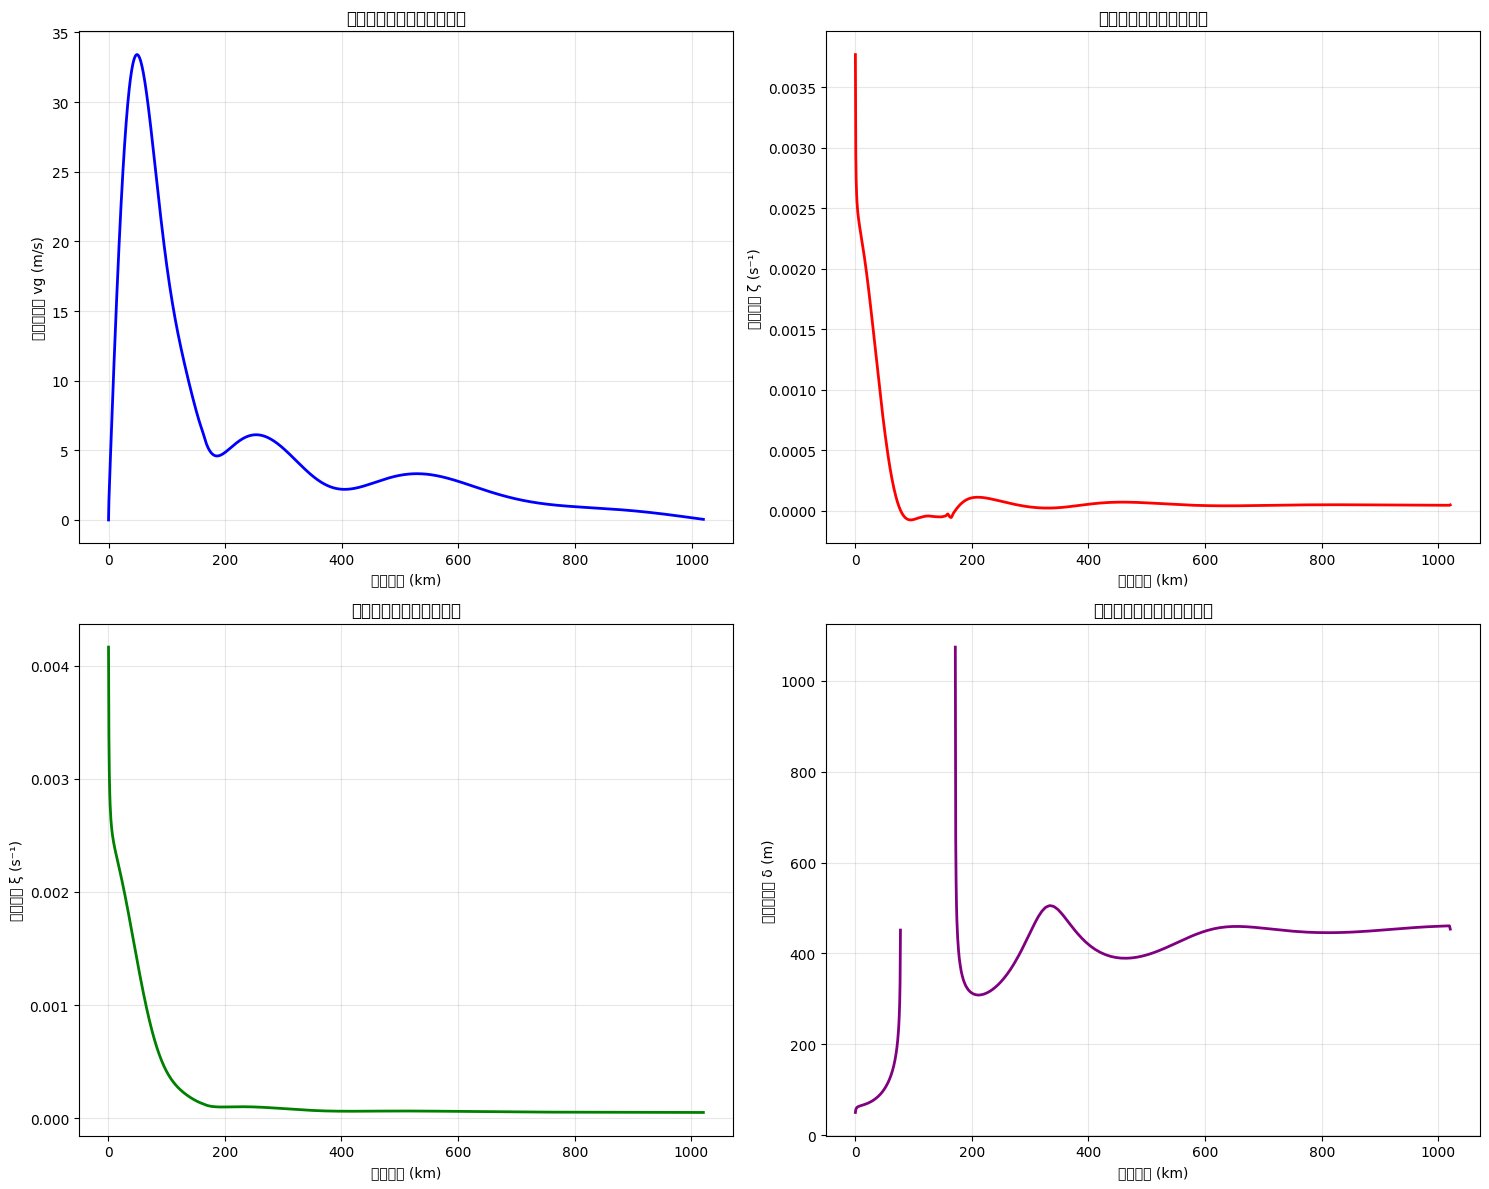

In [12]:
# 绘制四联图
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# vg-r 图
axes[0,0].plot(r_m_dense/1000.0, vg, 'b-', linewidth=2)
axes[0,0].set_xlabel('径向距离 (km)')
axes[0,0].set_ylabel('梯度风速度 vg (m/s)')
axes[0,0].set_title('梯度风速度随径向距离变化')
axes[0,0].grid(True, alpha=0.3)

# zeta-r 图
axes[0,1].plot(r_m_dense/1000.0, zeta, 'r-', linewidth=2)
axes[0,1].set_xlabel('径向距离 (km)')
axes[0,1].set_ylabel('相对涡度 ζ (s⁻¹)')
axes[0,1].set_title('相对涡度随径向距离变化')
axes[0,1].grid(True, alpha=0.3)

# xi-r 图
axes[1,0].plot(r_m_dense/1000.0, xi, 'g-', linewidth=2)
axes[1,0].set_xlabel('径向距离 (km)')
axes[1,0].set_ylabel('绝对涡度 ξ (s⁻¹)')
axes[1,0].set_title('绝对涡度随径向距离变化')
axes[1,0].grid(True, alpha=0.3)

# delta-r 图
axes[1,1].plot(r_m_dense/1000.0, delta, 'purple', linewidth=2)
axes[1,1].set_xlabel('径向距离 (km)')
axes[1,1].set_ylabel('边界层厚度 δ (m)')
axes[1,1].set_title('边界层厚度随径向距离变化')
axes[1,1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

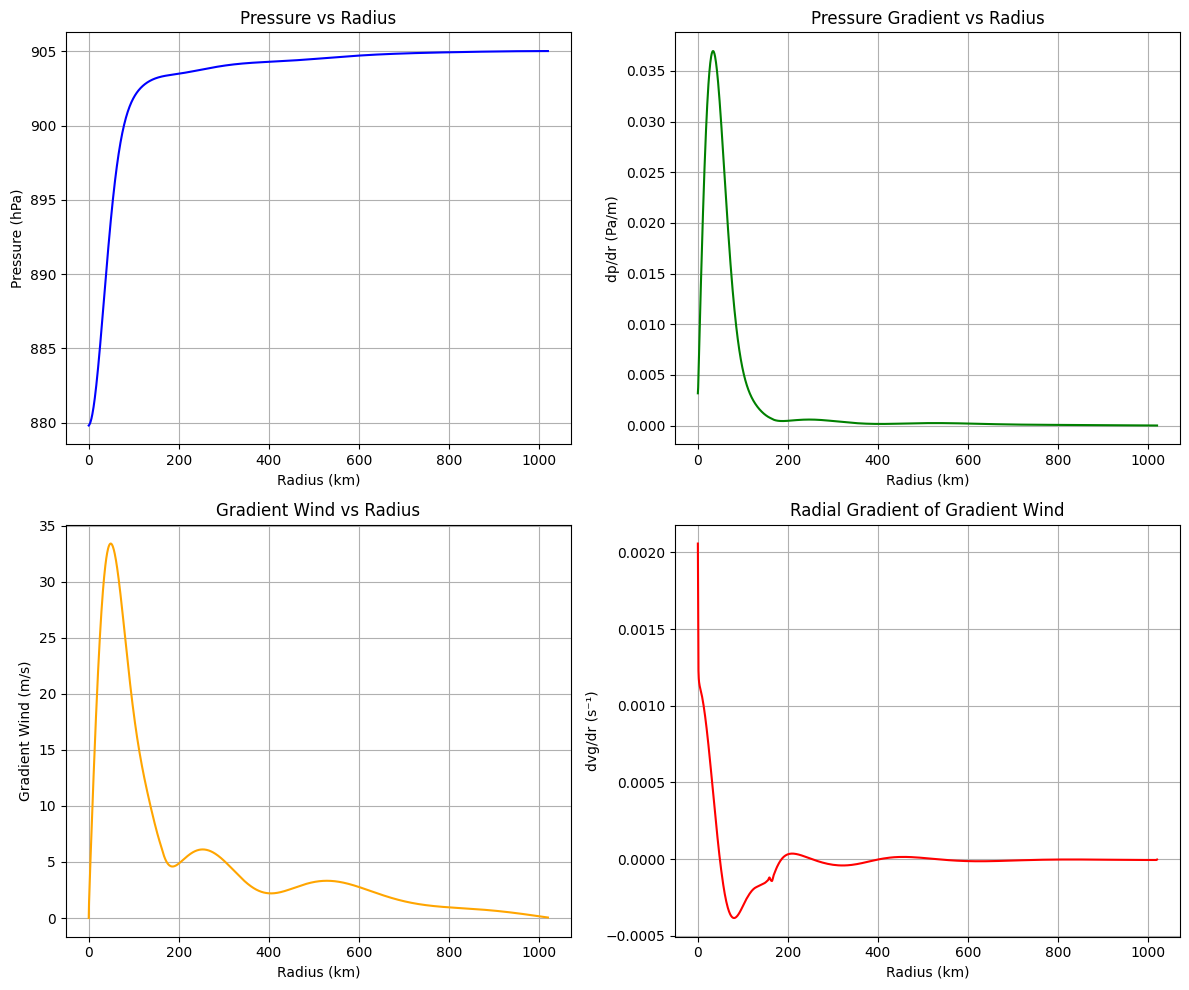

In [13]:

#绘制结果图
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# p-r图
axs[0,0].plot(r_m_dense/1000.0, p_pa_interp/100, color='blue')
axs[0,0].set_xlabel('Radius (km)')
axs[0,0].set_ylabel('Pressure (hPa)')
axs[0,0].set_title('Pressure vs Radius')
axs[0,0].grid()

# dpdr-r图
axs[0,1].plot(r_m_dense/1000.0, dpdr, color='green')
axs[0,1].set_xlabel('Radius (km)')
axs[0,1].set_ylabel('dp/dr (Pa/m)')
axs[0,1].set_title('Pressure Gradient vs Radius')
axs[0,1].grid()

# vg-r图
axs[1,0].plot(r_m_dense/1000.0, vg, color='orange')
axs[1,0].set_xlabel('Radius (km)')
axs[1,0].set_ylabel('Gradient Wind (m/s)')
axs[1,0].set_title('Gradient Wind vs Radius')
axs[1,0].grid()

# dvg/dr-r图
axs[1,1].plot(r_m_dense/1000.0, dvg_dr, color='red')
axs[1,1].set_xlabel('Radius (km)')
axs[1,1].set_ylabel('dvg/dr (s⁻¹)')
axs[1,1].set_title('Radial Gradient of Gradient Wind')
axs[1,1].grid()

plt.tight_layout()
plt.show()


In [ ]:

# 计算dvg/dr
dvgdr = np.full(N, np.nan)
if N >= 2:
    for i in range(1, N-1):
        dvg = vg[i+1] - vg[i-1]
        dr = r_m[i+1] - r_m[i-1]
        dvgdr[i] = dvg / dr if dr != 0 else np.nan
    dvgdr[0] = (vg[1] - vg[0]) / (r_m[1] - r_m[0])
    dvgdr[-1] = (vg[-1] - vg[-2]) / (r_m[-1] - r_m[-2])
result_dvgdr = np.column_stack((r_km, vg, dvgdr)) 
zeta=np.full(N, np.nan)
for i in range(N):
    zeta[i]=dvgdr[i] + vg[i]/r_m[i]+ f if r_m[i]!=0 else np.nan
result_zeta = np.column_stack((r_km, vg, dvgdr, zeta))
xi=np.full(N, np.nan)
for i in range(N):
    xi[i]=2*vg[i]/r_m[i]+ f if r_m[i]!=0 else np.nan
result_xi = np.column_stack((r_km, vg, dvgdr, zeta, xi))
#台风边界层湍流扩散系数
K=200.0  # m²/s
delta=np.full(N, np.nan)
for i in range(N):
    delta[i]=np.sqrt(K/np.sqrt(xi[i]*zeta[i])) if xi[i]!=0 else np.nan
result_A = np.column_stack((r_km, vg, dvgdr, zeta, xi, delta))
# ...existing code...
# 下面代码续写：生成 z-r 网格（z: 0..2 km，步长5 m），根据已有的 result_A（列：[r_km, vg, dvgdr, zeta, xi, delta]）
# 生成占位的 u,v,w（三个二维场，维度 (z, r)），并写出 output.nc（z,r 单位均为 km，变量单位 m s-1）。
import numpy as np
from netCDF4 import Dataset

# --- 参数 ---
z_top_km = 2.0
z_step_m = 5.0            # 5 m 间隔
z_km = np.arange(0.0, (2000 + 5)) / 1000.0  # 0..2.000 km 包含端点
# 或更稳妥的写法：
# z_km = np.arange(0, int(z_top_km*1000)+int(z_step_m), int(z_step_m)) / 1000.0

# 尝试从当前命名空间获取 r_km 和 result_A（已在上文计算得到）
try:
    r_km  # noqa: F821
except NameError:
    # 若 r_km 未定义，尝试从 arr 提取
    try:
        r_km = arr[:,0]
    except Exception:
        raise NameError("r_km 未定义且未找到 arr。请先运行前面的剖面提取生成 r_km 或 arr。")

try:
    result_A  # noqa: F821
except NameError:
    raise NameError("result_A 未定义。请先运行前面的 result_A 计算块。")

# 确认形状
r_km = np.asarray(r_km, dtype=float)
z_km = np.asarray(z_km, dtype=float)
nz = z_km.size
nr = r_km.size

# 提取 result_A 中常用量（假设列排列为 [r_km, vg, dvgdr, zeta, xi, delta]）
# 若列数不同，请根据实际调整索引
resA = np.asarray(result_A, dtype=float)
if resA.shape[1] < 6:
    raise ValueError("result_A 列数少于 6。需要至少包含 [r_km, vg, dvgdr, zeta, xi, delta]。")

vg_radial = resA[:,1].astype(float)     # 周向速度 vg (m/s)
dvgdr_radial = resA[:,2].astype(float)  # dvg/dr (1/s or m/s per m)
zeta_radial = resA[:,3].astype(float)
xi_radial = resA[:,4].astype(float)
delta_radial = resA[:,5].astype(float)

# 构建网格（Z, R）用于后续计算
R_grid, Z_grid = np.meshgrid(r_km, z_km)   # shapes (nz, nr), units km

# TODO: 用户将提供具体的 u,v,w 计算公式，下面仅给出示例占位实现（可直接替换）
# 占位策略（示例，仅作结构参考）：
# - 将径向上的周向速度 vg 分布延伸到竖直方向，并做简单的指数衰减（尺度可按需要改）
decay_scale_km = 0.5  # 竖直衰减尺度（km），示例值
vg_2d = np.tile(vg_radial, (nz, 1))               # (nz, nr)
vertical_decay = np.exp(-Z_grid / decay_scale_km) # (nz, nr)

# 示例字段（单位 m/s）
# v_t (周向分量) 使用 vg 乘以竖直衰减
v_field = vg_2d * vertical_decay

# u_field（径向分量）示例：取 dvg/dr 的负比例并垂直延伸（仅占位）
dvgdr_2d = np.tile(dvgdr_radial, (nz, 1))
u_field = -0.1 * dvgdr_2d * 1000.0 * vertical_decay  # 乘 1000 将单位从 per km -> per m（若需要）

# w_field（垂直分量）示例：使用 delta_radial 和简单缩放（占位）
delta_2d = np.tile(delta_radial, (nz, 1))
w_field = 0.01 * np.sqrt(np.abs(delta_2d)) * (1.0 - Z_grid / z_top_km)  # 仅示例

# 将网格单位从 km 保持为 km（坐标变量单位 km），字段单位 m/s（已近似）
u = np.asarray(u_field, dtype=np.float32)
v = np.asarray(v_field, dtype=np.float32)
w = np.asarray(w_field, dtype=np.float32)

# --- 写出 netCDF ---
out_file = "output.nc"
with Dataset(out_file, "w", format="NETCDF4") as nc:
    # 创建维度
    nc.createDimension("r", nr)
    nc.createDimension("z", nz)

    # 创建坐标变量
    r_var = nc.createVariable("r", "f4", ("r",))
    z_var = nc.createVariable("z", "f4", ("z",))
    r_var[:] = r_km.astype(np.float32)
    z_var[:] = z_km.astype(np.float32)
    r_var.units = "km"
    z_var.units = "km"
    r_var.long_name = "radial_distance"
    z_var.long_name = "height"

    # 创建速度场变量，维度顺序 (z, r)
    u_var = nc.createVariable("u", "f4", ("z", "r"), zlib=True, complevel=4)
    v_var = nc.createVariable("v", "f4", ("z", "r"), zlib=True, complevel=4)
    w_var = nc.createVariable("w", "f4", ("z", "r"), zlib=True, complevel=4)

    u_var[:, :] = u
    v_var[:, :] = v
    w_var[:, :] = w

    u_var.units = "m s-1"
    v_var.units = "m s-1"
    w_var.units = "m s-1"

    u_var.long_name = "radial_velocity_or_placeholder"
    v_var.long_name = "tangential_velocity_or_placeholder"
    w_var.long_name = "vertical_velocity_or_placeholder"

    nc.description = "Generated u,v,w fields on (z,r) grid. Replace placeholder computations with your formulas that use result_A."
    nc.history = "created by script"
    nc.source = "pressure_field.ipynb"

print(f"输出完成：{out_file} （维度 z={nz}, r={nr}），变量 u,v,w (m/s)。请把占位计算替换为你的具体公式。")


TypeError: 'NoneType' object is not callable

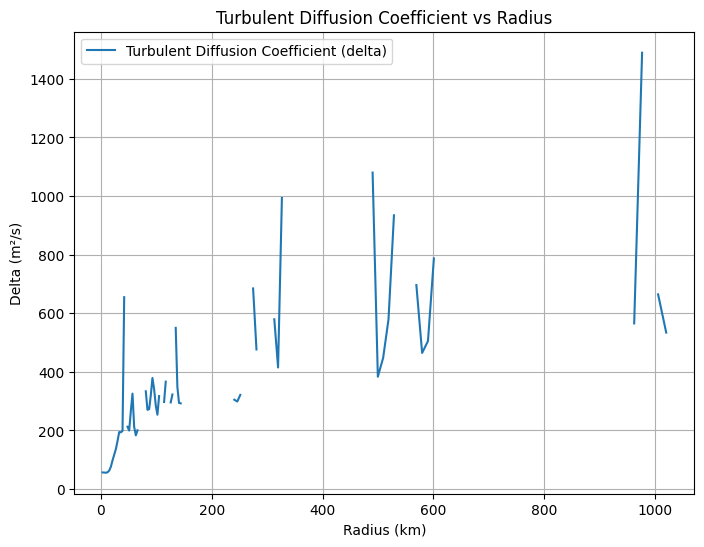